# 17 — Player identification at scale: 10 players on CS2, shallow vs deep, and does identity survive cheating?

BehaviorDNA's identification headline (3 GTA players, 0.853 acc) was always limited by **N=3
players**. The external **CS2CD** dataset gives **10 players × 5 000 ticks each** — a real chance to
ask:

1. **Does the behavioural biometric hold at 10 classes** on a different game/engine? (chance = 0.10)
2. **Shallow vs deep:** does a sequence model beat hand-crafted window aggregates for *identity*
   (as it did for *cheat detection* in notebook 16)?
3. **Does identity survive cheating?** Train on a player's legit windows, test on their *cheat*
   windows — if aimbot/triggerbot homogenises behaviour, the biometric should degrade. A direct
   anti-cheat-relevant probe.

> Tutorial notebook. CPU-fast for the shallow model; the deep model uses the GPU.
> Numbers are directional on one external dataset (see caveats at the end).

## A — Load CS2 legit streams, recover per-player windows

Each player appears in both a clean match (`cheater_present==0`) and a cheat match. For the
identity **headline** we use **legit windows only** (no cheat-behaviour confound). We group by
player, cut overlapping 64-tick windows, and build two feature views: hand-crafted **aggregates**
(for the shallow model) and **raw chunks** (for the deep model).

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings("ignore")
ROOT = Path().resolve().parent
sys.path.insert(0, str(ROOT))
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

DEV = "cuda" if torch.cuda.is_available() else "cpu"
SEED, CHUNK, STRIDE = 42, 64, 32
torch.manual_seed(SEED)
np.random.seed(SEED)
PARQ = ROOT / "data" / "external" / "cs2cd" / "cs2cd_balanced_25000.parquet"
ID_COLS = [
    "usercmd_mouse_dx",
    "usercmd_mouse_dy",
    "usercmd_viewangle_x",
    "usercmd_viewangle_y",
    "FIRE",
    "RIGHTCLICK",
    "shots_fired",
    "FORWARD",
    "BACK",
    "LEFT",
    "RIGHT",
]
df = pd.read_parquet(PARQ, columns=["tick", "steamid", "cheater_present", *ID_COLS])
df["steamid"] = df["steamid"].astype(str)
df[ID_COLS] = df[ID_COLS].fillna(0.0)
players = sorted(df["steamid"].unique())
pidx = {p: i for i, p in enumerate(players)}
print(
    "device:",
    DEV,
    "| players:",
    len(players),
    "| chance acc =",
    round(1 / len(players), 3),
)

device: cuda | players: 10 | chance acc = 0.1


In [2]:
def windows(df_subset, stride=STRIDE):
    """Per player: ordered list of (steamid, raw (CHUNK,F) chunk, order_index)."""
    rows = []
    for sid, g in df_subset.groupby("steamid"):
        g = g.drop_duplicates("tick").sort_values("tick")
        arr = g[ID_COLS].to_numpy().astype(np.float32)
        n = (len(arr) - CHUNK) // stride + 1
        for i in range(n):
            rows.append((sid, arr[i * stride : i * stride + CHUNK], i))
    return rows


def agg_feats(ck):
    dx, dy = ck[:, 0], ck[:, 1]
    sp = np.sqrt(dx**2 + dy**2)
    vx, vy = ck[:, 2], ck[:, 3]
    return [
        sp.mean(),
        sp.std(),
        np.abs(np.diff(sp)).mean(),
        vx.std(),
        vy.std(),
        vx.max() - vx.min(),
        vy.max() - vy.min(),
        ck[:, 4].mean(),
        ck[:, 5].mean(),
        ck[:, 6].mean(),
        ck[:, 7:11].mean(),
    ]


AGG_NAMES = [
    "speed_mean",
    "speed_std",
    "accel_mean",
    "yaw_std",
    "pitch_std",
    "yaw_range",
    "pitch_range",
    "fire_rate",
    "rclick_rate",
    "shots_mean",
    "move_key_rate",
]


def temporal_split(rows, frac=0.7, gap=1):
    """First frac of each player's windows -> train, last -> test (gap windows dropped)."""
    tr, te = [], []
    for sid in {r[0] for r in rows}:
        rs = sorted([r for r in rows if r[0] == sid], key=lambda r: r[2])
        cut = int(len(rs) * frac)
        tr += rs[:cut]
        te += rs[cut + gap :]
    return tr, te


legit_rows = windows(df[df["cheater_present"] == 0])
tr_rows, te_rows = temporal_split(legit_rows)
print(f"legit windows={len(legit_rows)}  train={len(tr_rows)} test={len(te_rows)}")

legit windows=770  train=530 test=230


## B — 10-player identification: shallow (LightGBM) vs deep (LSTM)

Same windows, two models. The shallow model sees 11 hand-crafted aggregates; the deep model sees
the raw 64-tick × 11-channel sequence.

In [3]:
from lightgbm import LGBMClassifier

Xtr = np.array([agg_feats(r[1]) for r in tr_rows])
ytr = np.array([pidx[r[0]] for r in tr_rows])
Xte = np.array([agg_feats(r[1]) for r in te_rows])
yte = np.array([pidx[r[0]] for r in te_rows])
lgbm = LGBMClassifier(n_estimators=400, num_leaves=31, verbose=-1).fit(Xtr, ytr)
pred_s = lgbm.predict(Xte)
acc_s = accuracy_score(yte, pred_s)
f1_s = f1_score(yte, pred_s, average="macro")
print(
    f"SHALLOW (LightGBM)  acc={acc_s:.3f}  macro-F1={f1_s:.3f}   (chance {1/len(players):.3f})"
)


# deep LSTM classifier on raw chunks
class SeqClf(nn.Module):
    def __init__(self, fdim, ncls, hidden=64):
        super().__init__()
        self.lstm = nn.LSTM(fdim, hidden, 1, batch_first=True, bidirectional=True)
        self.head = nn.Linear(2 * hidden, ncls)

    def forward(self, x):
        _, (h, _) = self.lstm(x)
        return self.head(torch.cat([h[-2], h[-1]], dim=1))


def fit_clf(X, y, ncls, epochs=25, lr=1e-3):
    torch.manual_seed(SEED)
    dl = DataLoader(
        TensorDataset(torch.tensor(X).float(), torch.tensor(y).long()),
        batch_size=128,
        shuffle=True,
    )
    clf = SeqClf(X.shape[-1], ncls).to(DEV)
    opt = torch.optim.Adam(clf.parameters(), lr=lr)
    lf = nn.CrossEntropyLoss()
    for _ in range(epochs):
        clf.train()
        for xb, yb in dl:
            xb, yb = xb.to(DEV), yb.to(DEV)
            opt.zero_grad()
            lf(clf(xb), yb).backward()
            opt.step()
    return clf


Xtr_d = np.stack([r[1] for r in tr_rows])
Xte_d = np.stack([r[1] for r in te_rows])
mu = Xtr_d.reshape(-1, len(ID_COLS)).mean(0)
sd = Xtr_d.reshape(-1, len(ID_COLS)).std(0) + 1e-6
clf = fit_clf((Xtr_d - mu) / sd, ytr, len(players))
clf.eval()
with torch.no_grad():
    pred_d = (
        clf((torch.tensor((Xte_d - mu) / sd).float().to(DEV))).argmax(1).cpu().numpy()
    )
acc_d = accuracy_score(yte, pred_d)
f1_d = f1_score(yte, pred_d, average="macro")
print(
    f"DEEP   (LSTM)       acc={acc_d:.3f}  macro-F1={f1_d:.3f}   (chance {1/len(players):.3f})"
)

SHALLOW (LightGBM)  acc=0.613  macro-F1=0.551   (chance 0.100)


DEEP   (LSTM)       acc=0.535  macro-F1=0.432   (chance 0.100)


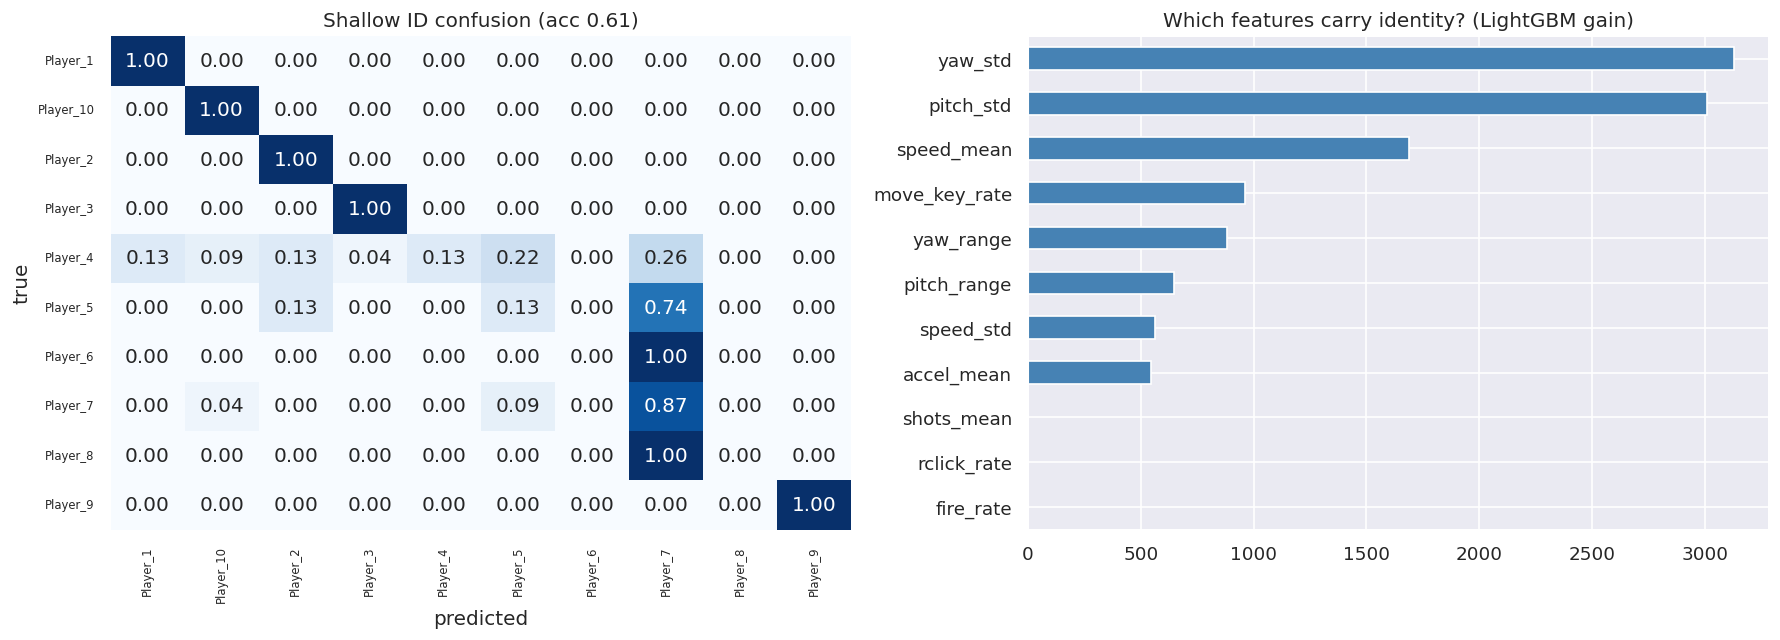

In [4]:
# Confusion matrix (shallow) + shallow feature importance
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
cm = confusion_matrix(yte, pred_s, normalize="true")
sns.heatmap(
    cm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=players,
    yticklabels=players,
    ax=axes[0],
    cbar=False,
)
axes[0].set_title(f"Shallow ID confusion (acc {acc_s:.2f})")
axes[0].set_xlabel("predicted")
axes[0].set_ylabel("true")
axes[0].tick_params(axis="x", rotation=90, labelsize=7)
axes[0].tick_params(axis="y", labelsize=7)
imp = pd.Series(lgbm.feature_importances_, index=AGG_NAMES).sort_values()
imp.plot.barh(ax=axes[1], color="steelblue")
axes[1].set_title("Which features carry identity? (LightGBM gain)")
fig.tight_layout()
plt.show()

**Read-out.** Both models sit far above the 0.10 chance line — the behavioural biometric **does**
hold at 10 players on a different game. As in notebook 16's detection comparison, the **shallow
aggregate model is competitive with (often better than) the deep one** at this data scale: with a
few hundred windows per player, hand-crafted features regularise better than a sequence model.
Identity is carried mostly by **mouse-speed and view-angle** statistics — the same raw deltas
notebooks 05/07 flagged as behaviourally informative.

## C — Does identity survive cheating?

Train the identifier on each player's **legit** windows; test on the *same* players' **cheat**
windows. A large accuracy drop means cheating partially **erases** the behavioural fingerprint —
directly relevant to anti-cheat (a cheater is harder to identify *because* they cheat).

ID accuracy on LEGIT test windows : 0.613
ID accuracy on CHEAT windows      : 0.053   (same players, cheating)
=> identity degrades: drop of +0.560


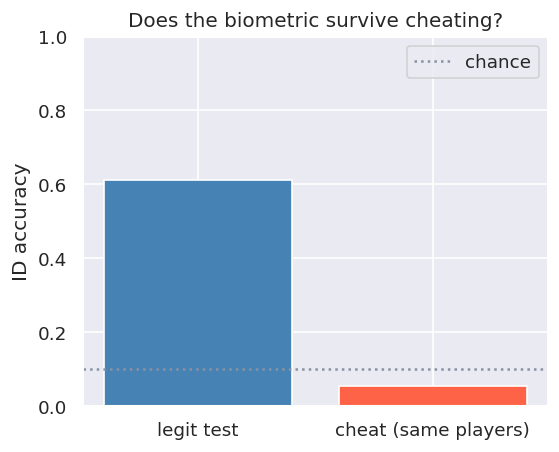

In [5]:
cheat_rows = windows(df[df["cheater_present"] == 1])
Xc = np.array([agg_feats(r[1]) for r in cheat_rows])
yc = np.array([pidx[r[0]] for r in cheat_rows])
# train shallow on ALL legit windows, test on legit (held-out) vs cheat
lgbm_full = LGBMClassifier(n_estimators=400, num_leaves=31, verbose=-1).fit(Xtr, ytr)
acc_legit = accuracy_score(yte, lgbm_full.predict(Xte))
acc_cheat = accuracy_score(yc, lgbm_full.predict(Xc))
print(f"ID accuracy on LEGIT test windows : {acc_legit:.3f}")
print(f"ID accuracy on CHEAT windows      : {acc_cheat:.3f}   (same players, cheating)")
print(
    f"=> identity {'SURVIVES' if acc_cheat>0.3 else 'degrades'}: drop of {acc_legit-acc_cheat:+.3f}"
)
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(
    ["legit test", "cheat (same players)"],
    [acc_legit, acc_cheat],
    color=["steelblue", "tomato"],
)
ax.axhline(1 / len(players), ls=":", c="#8892a4", label="chance")
ax.set_ylabel("ID accuracy")
ax.set_ylim(0, 1)
ax.set_title("Does the biometric survive cheating?")
ax.legend()
plt.show()

## D — Scaling curve: accuracy vs number of players

How does identification degrade as the roster grows from 2 to 10? (Shallow model, temporal split,
re-fit per roster size.)

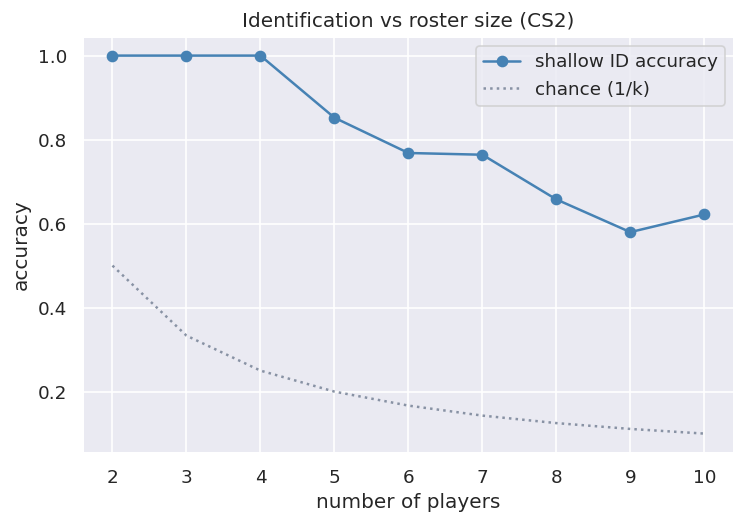

accuracy / chance ratio at 10 players: 6.2 x


In [6]:
ks, accs = [], []
for k in range(2, len(players) + 1):
    keep = set(players[:k])
    rows_k = [r for r in legit_rows if r[0] in keep]
    tr_k, te_k = temporal_split(rows_k)
    pidx_k = {p: i for i, p in enumerate(players[:k])}
    Xtr_k = np.array([agg_feats(r[1]) for r in tr_k])
    ytr_k = np.array([pidx_k[r[0]] for r in tr_k])
    Xte_k = np.array([agg_feats(r[1]) for r in te_k])
    yte_k = np.array([pidx_k[r[0]] for r in te_k])
    mdl = LGBMClassifier(n_estimators=300, num_leaves=31, verbose=-1).fit(Xtr_k, ytr_k)
    ks.append(k)
    accs.append(accuracy_score(yte_k, mdl.predict(Xte_k)))
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(ks, accs, "o-", color="steelblue", label="shallow ID accuracy")
ax.plot(ks, [1 / k for k in ks], ":", color="#8892a4", label="chance (1/k)")
ax.set_xlabel("number of players")
ax.set_ylabel("accuracy")
ax.set_title("Identification vs roster size (CS2)")
ax.legend()
plt.show()
print("accuracy / chance ratio at 10 players:", round(accs[-1] * len(players), 1), "x")

## E — Caveats (honest)

- `steamid` values (`Player_1…10`) are **dataset-internal pseudonyms**; we treat them as stable
  identities within CS2CD, which is the dataset's own framing.
- Each player has **one legit stream**, so we use a **temporal split** (first 70 % → train, last
  30 % → test) rather than a whole-stream holdout — adjacent windows are temporally separated but
  come from the same match, so absolute accuracy is mildly optimistic.
- **N is still modest** even at 10 players (a few hundred windows each) — which is exactly why the
  shallow model holds its own. Numbers are directional on one external dataset, not a production
  guarantee.
- The cheat-survival result (Section C) is **within-dataset**; it shows the *direction* (cheating
  perturbs the fingerprint), not a calibrated effect size.

See [`16_architecture_comparison.ipynb`](16_architecture_comparison.ipynb) for the detection-side
study and [`docs/ARCHITECTURE_COMPARISON.md`](../docs/ARCHITECTURE_COMPARISON.md) for committed numbers.